# Machine Learning Lab (23CSE301) – Exercise Solutions
**Chapter 6**


In [1]:
# ---- Common imports and dataset loader ----
import os, re, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

# ---- Dataset loader ----
DATA_DIR = "data"
def load_data(filename, url, **read_csv_kwargs):
    """Read a real dataset. Uses ./data/<filename> if present (e.g. downloaded from Kaggle);
    otherwise downloads the public copy given in `url` and caches it in ./data/."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        os.makedirs(DATA_DIR, exist_ok=True)
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp, open(path, "wb") as f:
            f.write(resp.read())
    return pd.read_csv(path, **read_csv_kwargs)

print("Libraries loaded")

Libraries loaded


# 6.6 Logistic Regression – Exercises
## Exercise 1 – Graduate-school admission (GRE, GPA, institution prestige)
Binary response: `admit` (1 = likely admitted, 0 = not).

> **Dataset – Graduate Admissions (Kaggle: `mohansacharya/graduate-admissions`, file `Admission_Predict_Ver1.1.csv`).**
> Link: <https://www.kaggle.com/datasets/mohansacharya/graduate-admissions>
> It is *inspired by* the UCLA admissions data (it is not the original `admit/gre/gpa/rank` file).
> **Records:** 500 applicants · **Features:** `gre` (GRE score, /340), `gpa` (CGPA, /10), `rank` (University Rating 1–5; **5 = most prestigious**, the opposite direction of the UCLA `rank`) · **Target:** `admit`.
> **Preprocessing:** the dataset has no yes/no label – only `Chance of Admit` (0.34–0.97) – so `admit = 1` when `Chance of Admit >= 0.75` (≈ 44 % of applicants). `rank` is one-hot encoded. TOEFL, SOP, LOR and Research are not used because the exercise only names GRE, GPA and prestige.
> **Why it fits:** same three predictors as the exercise (test score, GPA, institution prestige) on real applicant data.

In [10]:
grad_raw = load_data("Admission_Predict_Ver1.1.csv",
                     "https://raw.githubusercontent.com/divyansha1115/Graduate-Admission-Prediction/master/Admission_Predict_Ver1.1.csv")
grad_raw.columns = grad_raw.columns.str.strip()          # 'LOR ' / 'Chance of Admit ' have trailing spaces

adm = pd.DataFrame({
    "admit": (grad_raw["Chance of Admit"] >= 0.75).astype(int),
    "gre":   grad_raw["GRE Score"],
    "gpa":   grad_raw["CGPA"],
    "rank":  grad_raw["University Rating"],
})
print(adm.shape)
print("Null values:", adm.isnull().sum().sum())
print("\nAdmission rate:", adm["admit"].mean().round(3))
adm.head()

(500, 4)
Null values: 0

Admission rate: 0.436


,admit,gre,gpa,rank
0,1,337,9.65,4
1,1,324,8.87,4
2,0,316,8.00,3
3,1,322,8.67,3
4,0,314,8.21,2


In [11]:
# Prestige (rank) is categorical -> one-hot encode; GRE / GPA are numeric
X = pd.concat([adm[["gre", "gpa"]], pd.get_dummies(adm["rank"], prefix="rank", drop_first=True).astype(int)], axis=1)
y = adm["admit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=5, stratify=y)

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(C=1e6, max_iter=5000)      # C very large ~ no regularisation
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

coef = pd.DataFrame({"feature": X.columns, "coefficient": clf.coef_[0], "odds_ratio": np.exp(clf.coef_[0])})
print("Intercept:", clf.intercept_.round(3))
coef.round(4)

Intercept: [-68.049]


,feature,coefficient,odds_ratio
0,gre,0.0872,1.0911
1,gpa,4.5941,98.8979
2,rank_2,-0.5919,0.5533
3,rank_3,0.5572,1.7457
4,rank_4,0.7505,2.1180
5,rank_5,1.7723,5.8844


Confusion matrix:
 [[63  8]
 [ 5 49]]

Accuracy : 0.896
ROC-AUC  : 0.968

              precision    recall  f1-score   support

Not admitted       0.93      0.89      0.91        71
    Admitted       0.86      0.91      0.88        54

    accuracy                           0.90       125
   macro avg       0.89      0.90      0.89       125
weighted avg       0.90      0.90      0.90       125



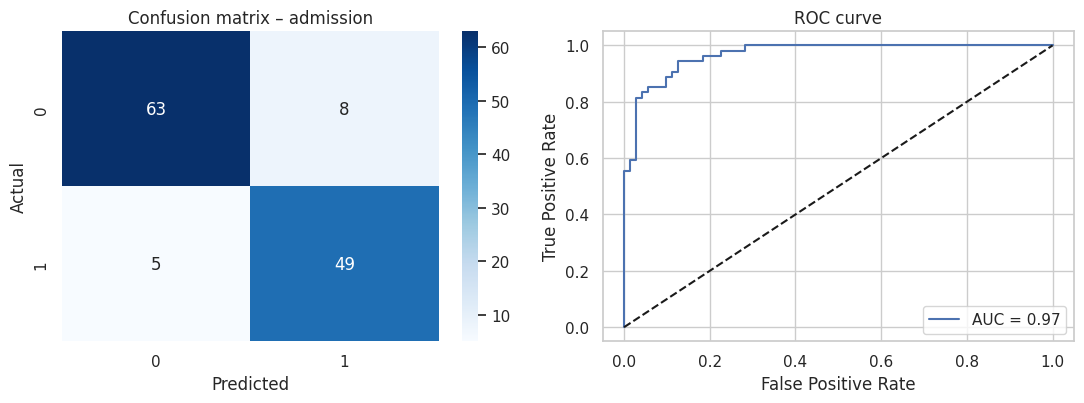

In [12]:
print("Confusion matrix:\n", metrics.confusion_matrix(y_test, y_pred))
print(f"\nAccuracy : {metrics.accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {metrics.roc_auc_score(y_test, y_prob):.3f}\n")
print(metrics.classification_report(y_test, y_pred, target_names=["Not admitted", "Admitted"]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
sns.heatmap(pd.crosstab(y_test, y_pred, rownames=["Actual"], colnames=["Predicted"]), annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title("Confusion matrix – admission")
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, label=f"AUC = {metrics.auc(fpr, tpr):.2f}"); ax[1].plot([0, 1], [0, 1], "k--")
ax[1].set(title="ROC curve", xlabel="False Positive Rate", ylabel="True Positive Rate"); ax[1].legend()
plt.tight_layout(); plt.show()

In [13]:
# Admission probability for a new applicant: GRE 320, CGPA 9.0 - top-rated (5) vs lowest-rated (1) university
def applicant(gre, gpa, rating):
    row = {"gre": gre, "gpa": gpa, **{f"rank_{r}": int(rating == r) for r in range(2, 6)}}
    return pd.DataFrame([row], columns=X.columns)

for rating in (5, 1):
    print(f"P(admit) for GRE=320, CGPA=9.0, University Rating={rating} : {clf.predict_proba(applicant(320, 9.0, rating))[0, 1]:.2%}")

P(admit) for GRE=320, CGPA=9.0, University Rating=5 : 95.07%
P(admit) for GRE=320, CGPA=9.0, University Rating=1 : 76.64%


## Exercise 2 – Is a person susceptible to a certain disease?

> **Dataset – Pima Indians Diabetes Database (Kaggle: `uciml/pima-indians-diabetes-database`).**
> Link: <https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database>
> **Records:** 768 women · **Features:** `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age` · **Target:** `disease` (= `Outcome`, 1 = tested positive for diabetes).
> **Preprocessing:** in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` and `BMI` a value of 0 is physiologically impossible, so 0 is treated as *missing* and replaced by the training-set median; features are standardised.
> **Why it fits:** a real medical table with a binary "susceptible / not susceptible" outcome – the classic logistic-regression medical example (replaces the DATAtab *Medical example* file, which is not on Kaggle).

In [14]:
pima = load_data("diabetes.csv",
                 "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv")
med = pima.rename(columns={"Outcome": "disease"})

# 0 is not a valid measurement for these columns -> treat as missing
zero_is_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
med[zero_is_missing] = med[zero_is_missing].replace(0, np.nan)

print(med.shape, "| disease prevalence:", med.disease.mean().round(3))
print("Missing values per column (after 0 -> NaN):", med.isnull().sum()[med.isnull().sum() > 0].to_dict())
med.head()

(768, 9) | disease prevalence: 0.349
Missing values per column (after 0 -> NaN): {'Glucose': 5, 'BloodPressure': 35, 'SkinThickness': 227, 'Insulin': 374, 'BMI': 11}


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,disease
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


Confusion matrix:
 [[91  9]
 [28 26]]

Accuracy: 0.760 | AUC: 0.830

              precision    recall  f1-score   support

     Healthy       0.76      0.91      0.83       100
 Susceptible       0.74      0.48      0.58        54

    accuracy                           0.76       154
   macro avg       0.75      0.70      0.71       154
weighted avg       0.76      0.76      0.74       154



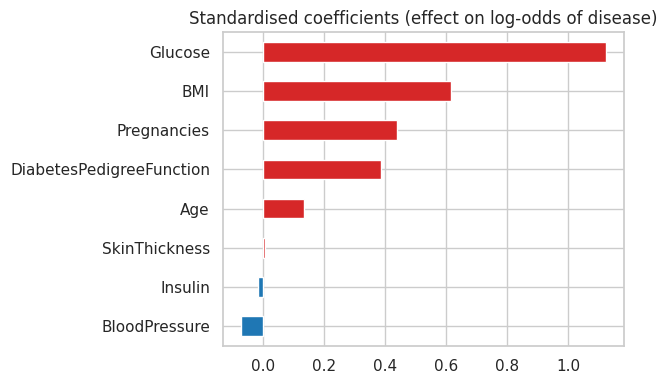

In [15]:
from sklearn.impute import SimpleImputer

X = med.drop(columns="disease"); y = med["disease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

imp = SimpleImputer(strategy="median")            # medians learned on the training set only
sc  = StandardScaler()
X_train_s = sc.fit_transform(imp.fit_transform(X_train))
X_test_s  = sc.transform(imp.transform(X_test))

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)
y_prob = clf.predict_proba(X_test_s)[:, 1]

print("Confusion matrix:\n", metrics.confusion_matrix(y_test, y_pred))
print(f"\nAccuracy: {metrics.accuracy_score(y_test, y_pred):.3f} | AUC: {metrics.roc_auc_score(y_test, y_prob):.3f}\n")
print(metrics.classification_report(y_test, y_pred, target_names=["Healthy", "Susceptible"]))

imp_coef = pd.Series(clf.coef_[0], index=X.columns).sort_values()
plt.figure(figsize=(6.5, 4))
imp_coef.plot.barh(color=["tab:red" if v > 0 else "tab:blue" for v in imp_coef])
plt.title("Standardised coefficients (effect on log-odds of disease)"); plt.tight_layout(); plt.show()

In [16]:
# Risk prediction for one new patient
patient = pd.DataFrame([{"Pregnancies": 2, "Glucose": 150, "BloodPressure": 80, "SkinThickness": 35,
                         "Insulin": 160, "BMI": 33.0, "DiabetesPedigreeFunction": 0.6, "Age": 50}])[X.columns]
p = clf.predict_proba(sc.transform(imp.transform(patient)))[0, 1]
print(f"Probability of being susceptible: {p:.1%}  ->  {'Susceptible' if p >= 0.5 else 'Not susceptible'}")

Probability of being susceptible: 56.3%  ->  Susceptible


## Exercise 3 – Which product is a customer most likely to buy? (online retailer)
The exercise describes 3 product classes (**multinomial logistic regression**, softmax); the real dataset below has **2 outcomes** (buys / does not buy), so the same multinomial code runs with two classes and would work unchanged with more.

> **Dataset – Social Network Ads (Kaggle: `rakeshrau/social-network-ads`).**
> Link: <https://www.kaggle.com/datasets/rakeshrau/social-network-ads>
> **Records:** 400 users · **Features:** `Age`, `EstimatedSalary`, `Gender` (one-hot) · **Target:** `product` (`Buys product` = `Purchased` 1 / `Does not buy` = 0).
> **Preprocessing:** dropped `User ID`; Gender one-hot encoded; features standardised; stratified 80/20 split.
> **Why it fits:** real customer data (age, income, purchase decision) for an online-advertising / purchase scenario; no real multi-class product column was available, so the target is binary.

In [17]:
ads = load_data("Social_Network_Ads.csv",
                "https://raw.githubusercontent.com/sharmaroshan/Social-Networks-Ads/master/Social_Network_Ads.csv")
cust = ads.drop(columns="User ID")
cust["product"] = cust.pop("Purchased").map({1: "Buys product", 0: "Does not buy"})

print(cust.shape, "| nulls:", cust.isnull().sum().sum())
print(cust["product"].value_counts(), "\n")
cust.head()

(400, 4) | nulls: 0
product
Does not buy    257
Buys product    143
Name: count, dtype: int64 



,Gender,Age,EstimatedSalary,product
0,Male,19.0,19000.0,Does not buy
1,Male,35.0,20000.0,Does not buy
2,Female,26.0,43000.0,Does not buy
3,Female,27.0,57000.0,Does not buy
4,Male,19.0,76000.0,Does not buy


Accuracy: 0.863

              precision    recall  f1-score   support

Buys product       0.88      0.72      0.79        29
Does not buy       0.86      0.94      0.90        51

    accuracy                           0.86        80
   macro avg       0.87      0.83      0.84        80
weighted avg       0.86      0.86      0.86        80



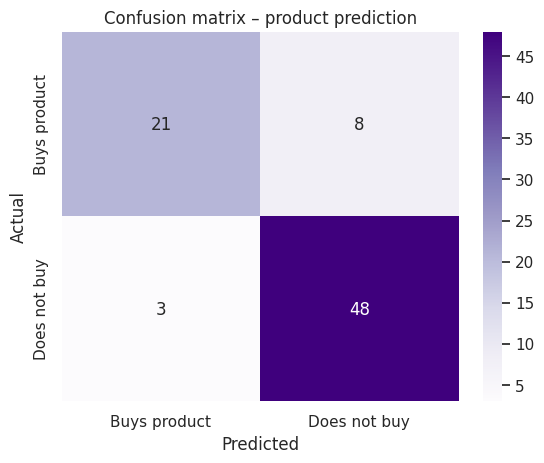

In [18]:
X = pd.get_dummies(cust.drop(columns="product"), columns=["Gender"], drop_first=True).astype(float)
y = cust["product"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

sc = StandardScaler()
X_train_s, X_test_s = sc.fit_transform(X_train), sc.transform(X_test)

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)      # multinomial (softmax) by default
y_pred = clf.predict(X_test_s)

print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred):.3f}\n")
print(metrics.classification_report(y_test, y_pred))

labels = clf.classes_
sns.heatmap(pd.DataFrame(metrics.confusion_matrix(y_test, y_pred, labels=labels), index=labels, columns=labels),
            annot=True, fmt="d", cmap="Purples")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion matrix – product prediction"); plt.show()

Buys product    0.006
Does not buy    0.994

Most likely outcome -> Does not buy  (99.4%)


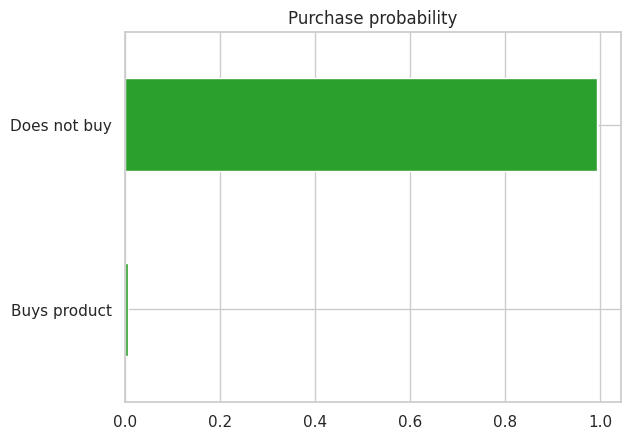

In [19]:
# Will this customer buy?  (24 years old, estimated salary 45,000, female)
new_customer = pd.DataFrame([{"Age": 24, "EstimatedSalary": 45000, "Gender_Male": 0.0}])[X.columns]
proba = pd.Series(clf.predict_proba(sc.transform(new_customer))[0], index=clf.classes_)
print(proba.round(3).to_string())
print(f"\nMost likely outcome -> {proba.idxmax()}  ({proba.max():.1%})")
proba.sort_values().plot.barh(color="tab:green", title="Purchase probability"); plt.show()